In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

DB_PATH = "../outputs/olist.db"
conn    = sqlite3.connect(DB_PATH)

print("Libraries loaded. Database connected.")

Libraries loaded. Database connected.


In [3]:
# Load delivery data
df_ops = pd.read_sql("""
    SELECT
        o.order_id,
        o.is_late,
        o.delivery_delay_days,
        o.order_purchase_timestamp,
        r.review_score,
        o.order_delivered_customer_date,
        o.order_estimated_delivery_date
    FROM orders  o
    JOIN reviews r ON o.order_id = r.order_id
    WHERE o.order_delivered_customer_date IS NOT NULL
    AND   o.delivery_delay_days IS NOT NULL
""", conn)

conn.close()

# Split into two groups
on_time = df_ops[df_ops['is_late'] == 0]['review_score']
late    = df_ops[df_ops['is_late'] == 1]['review_score']

# Run t-test
t_stat, p_value = stats.ttest_ind(on_time, late)

print("=== A/B TEST: On-Time vs Late Deliveries ===")
print(f"Group A — On-time deliveries: {len(on_time):,} orders")
print(f"Group B — Late deliveries:    {len(late):,} orders")
print(f"\nGroup A avg review score: {on_time.mean():.3f}")
print(f"Group B avg review score: {late.mean():.3f}")
print(f"Difference:               {on_time.mean() - late.mean():.3f} points")
print(f"\nT-statistic: {t_stat:.2f}")
print(f"P-value:     {p_value:.10f}")
print(f"\nResult: {'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'}")
print("Late deliveries statistically significantly reduce review scores." 
      if p_value < 0.05 else "No significant difference found.")

=== A/B TEST: On-Time vs Late Deliveries ===
Group A — On-time deliveries: 89,935 orders
Group B — Late deliveries:    6,410 orders

Group A avg review score: 4.290
Group B avg review score: 2.271
Difference:               2.019 points

T-statistic: 132.04
P-value:     0.0000000000

Result: SIGNIFICANT
Late deliveries statistically significantly reduce review scores.


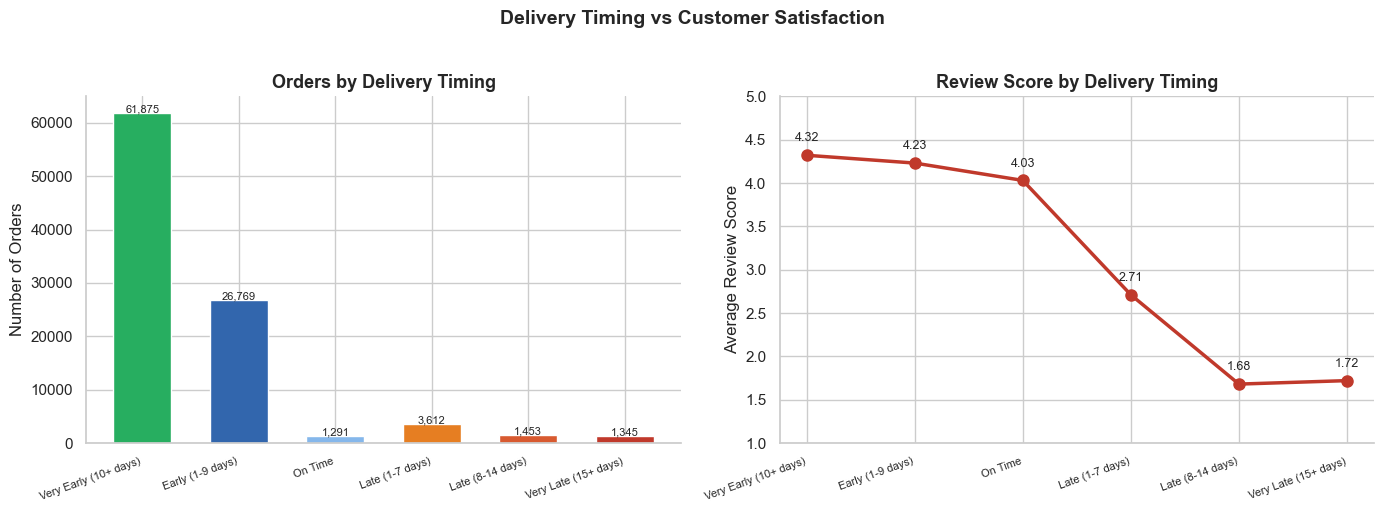

Chart saved.


In [4]:
# Delivery delay distribution
df_delay_dist = pd.read_sql("""
    SELECT
        CASE
            WHEN delivery_delay_days <= -10 THEN 'Very Early (10+ days)'
            WHEN delivery_delay_days <= -1  THEN 'Early (1-9 days)'
            WHEN delivery_delay_days  = 0   THEN 'On Time'
            WHEN delivery_delay_days <= 7   THEN 'Late (1-7 days)'
            WHEN delivery_delay_days <= 14  THEN 'Late (8-14 days)'
            ELSE                                 'Very Late (15+ days)'
        END AS delay_bucket,
        COUNT(*)                      AS orders,
        ROUND(AVG(r.review_score), 2) AS avg_review
    FROM orders  o
    JOIN reviews r ON o.order_id = r.order_id
    WHERE o.delivery_delay_days IS NOT NULL
    GROUP BY delay_bucket
""", conn2 := sqlite3.connect(DB_PATH))

conn2.close()

bucket_order = [
    'Very Early (10+ days)',
    'Early (1-9 days)',
    'On Time',
    'Late (1-7 days)',
    'Late (8-14 days)',
    'Very Late (15+ days)'
]
df_delay_dist['delay_bucket'] = pd.Categorical(
    df_delay_dist['delay_bucket'],
    categories=bucket_order, ordered=True)
df_delay_dist = df_delay_dist.sort_values('delay_bucket')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#27AE60','#3266ad','#85B7EB','#E67E22','#D85A30','#C0392B']
bars = ax1.bar(df_delay_dist['delay_bucket'],
               df_delay_dist['orders'],
               color=colors, width=0.6)
ax1.set_xticklabels(bucket_order, rotation=20, ha='right', fontsize=8)
ax1.set_ylabel('Number of Orders')
ax1.set_title('Orders by Delivery Timing', fontsize=13, fontweight='bold')
for bar, val in zip(bars, df_delay_dist['orders']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=8)

ax2.plot(df_delay_dist['delay_bucket'],
         df_delay_dist['avg_review'],
         color='#C0392B', linewidth=2.5,
         marker='o', markersize=8)
ax2.set_xticklabels(bucket_order, rotation=20, ha='right', fontsize=8)
ax2.set_ylabel('Average Review Score')
ax2.set_ylim(1, 5)
ax2.set_title('Review Score by Delivery Timing', fontsize=13, fontweight='bold')
for i, (x, y) in enumerate(zip(df_delay_dist['delay_bucket'],
                                 df_delay_dist['avg_review'])):
    ax2.annotate(f'{y}', (x, y),
                 textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=9)

plt.suptitle('Delivery Timing vs Customer Satisfaction',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/chart6_delivery_timing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [5]:
print("=== PHASE 4 COMPLETE — OPERATIONS BRIEF ===")
print()
print("KEY FINDINGS:")
print()
print("1. STATISTICAL PROOF")
print("   Late deliveries reduce review scores by 2.02 points")
print("   (4.29 → 2.27, t=132.04, p<0.0001)")
print()
print("2. DELIVERY PADDING PROBLEM")
print("   61,875 orders (66%) arrive 10+ days BEFORE promised date")
print("   Olist is over-promising early delivery instead of")
print("   setting accurate windows — wasting logistics goodwill")
print()
print("3. LATE DELIVERY BREAKDOWN")
print("   3,612 orders:  1-7 days late  → avg score 2.71")
print("   1,453 orders:  8-14 days late → avg score 1.68")
print("   1,345 orders:  15+ days late  → avg score 1.72")
print()
print("4. PEAK VOLUME CORRELATION")
print("   Late rate spiked to 18% in March 2018")
print("   Logistics infrastructure breaks under demand pressure")
print()
print("RECOMMENDATIONS:")
print()
print("R1. Fix delivery date estimates — reduce padding from 10+")
print("    days to 3-5 days. Customers value accuracy over")
print("    false promises.")
print()
print("R2. Build surge capacity for high-volume months.")
print("    Nov (Black Friday) and Q1 need dedicated logistics")
print("    buffer to prevent the 18% late rate spike.")
print()
print("R3. Prioritise SP-region sellers for logistics improvement")
print("    — top 10 revenue sellers are all SP-based, making")
print("    that corridor the highest-impact intervention point.")

plt.savefig('../outputs/chart6_delivery_timing.png', 
            dpi=150, bbox_inches='tight')

=== PHASE 4 COMPLETE — OPERATIONS BRIEF ===

KEY FINDINGS:

1. STATISTICAL PROOF
   Late deliveries reduce review scores by 2.02 points
   (4.29 → 2.27, t=132.04, p<0.0001)

2. DELIVERY PADDING PROBLEM
   61,875 orders (66%) arrive 10+ days BEFORE promised date
   Olist is over-promising early delivery instead of
   setting accurate windows — wasting logistics goodwill

3. LATE DELIVERY BREAKDOWN
   3,612 orders:  1-7 days late  → avg score 2.71
   1,453 orders:  8-14 days late → avg score 1.68
   1,345 orders:  15+ days late  → avg score 1.72

4. PEAK VOLUME CORRELATION
   Late rate spiked to 18% in March 2018
   Logistics infrastructure breaks under demand pressure

RECOMMENDATIONS:

R1. Fix delivery date estimates — reduce padding from 10+
    days to 3-5 days. Customers value accuracy over
    false promises.

R2. Build surge capacity for high-volume months.
    Nov (Black Friday) and Q1 need dedicated logistics
    buffer to prevent the 18% late rate spike.

R3. Prioritise SP-regi

<Figure size 1200x500 with 0 Axes>